# Auditoría de confianza — Medir antes de corregir

## Objetivo del notebook
Realizar una **auditoría completa de confianza** sobre modelos ya entrenados,
sin aplicar ninguna técnica de calibración.

El foco está en **medir**, no en mejorar.

---

## Alcance
- Modelos auditados:
  - Regresión Logística
  - Árbol de Decisión
- Métricas:
  - Accuracy
  - AUROC
  - Brier Score
  - Expected Calibration Error (ECE)
- Visualizaciones:
  - Reliability diagrams comparativos

La comparación se hará **ignorando la accuracy** como criterio principal
y priorizando métricas de **confiabilidad**.

---

## Regla clave
En este notebook **no se corrigen probabilidades**.
Cualquier ajuste o calibración queda fuera de alcance.

---
---

## Imports y carga de utilidades

### ¿Qué vamos a hacer?
Vamos a cargar las librerías necesarias para la auditoría de confianza
y reutilizar las funciones definidas en el setup.

### ¿Por qué importa?
Este notebook **no entrena modelos**.
Solo mide y compara, por lo que reutilizar exactamente las mismas
utilidades garantiza consistencia con el Día 1.

In [11]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Métricas
from sklearn.metrics import accuracy_score, roc_auc_score

# Cargar utilidades comunes
import sys
sys.path.append("../00_setup")

from environment_and_utils import (
    brier_score,
    expected_calibration_error,
    plot_reliability_diagram,
)

## Reconstrucción del experimento base (reproducible)

Este notebook debe poder ejecutarse de principio a fin sin depender del Día 1.
Por eso, reconstruimos exactamente:
- el dataset sintético,
- el split train/test,
- y el entrenamiento de los 2 modelos (sin tuning).

A partir de ahí, realizamos la auditoría de confianza.

In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Dataset sintético (mismos parámetros)
X, y = make_classification(
    n_samples=4000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=2,
    class_sep=1.0,
    flip_y=0.05,
    random_state=42
)

# Split train/test (mismo split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [13]:
# Entrenar modelos (mismos hiperparámetros)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [14]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [15]:
# Predicciones y probabilidades (clase 1)
y_pred_lr = log_reg.predict(X_test)
probs_lr = log_reg.predict_proba(X_test)[:, 1]

In [16]:
y_pred_tree = tree.predict(X_test)
probs_tree = tree.predict_proba(X_test)[:, 1]

## 4) Métricas de auditoría (scorecard)

### ¿Qué vamos a hacer?
Vamos a calcular un conjunto reducido de métricas para entender **dos cosas distintas**:

1. **Qué tan bien el modelo predice clases**  
2. **Qué tan confiables son las probabilidades que entrega**

Ambas cosas son importantes, pero **no significan lo mismo**.

---

### Métricas que vamos a usar

- **Accuracy**  
  Mide cuántas predicciones de clase son correctas.  
  Responde a la pregunta: *“¿cuántas veces acierta el modelo?”*  
  La usamos solo como **referencia**, no para decidir.

- **AUROC**  
  Mide qué tan bien el modelo **ordena los casos** desde los más probables
  hasta los menos probables.  
  Responde a la pregunta: *“¿el modelo pone arriba los casos más positivos?”*  
  Un AUROC alto no garantiza probabilidades confiables.

- **Brier Score**  
  Mide qué tan lejos están las probabilidades del resultado real.  
  Penaliza fuertemente los errores cuando el modelo estaba muy seguro.  
  Cuanto más bajo, **mejor calidad de probabilidad**.

- **Expected Calibration Error (ECE)**  
  Mide cuánto se desvían, en promedio, las probabilidades del modelo
  respecto a lo que realmente ocurre.  
  Responde a la pregunta: *“cuando el modelo dice 80%, ¿ocurre algo cercano a 80%?”*

---

### ¿Por qué importa esta auditoría?
Porque un modelo puede:
- acertar muchas veces,
- ordenar bien los casos,
- y aun así **decir números que no significan lo que parecen**.

Es decir:
> puede “predecir bien”, pero **comunicar mal su confianza**.

---

### Qué vamos a decidir con esta tabla
Esta scorecard no sirve para elegir el modelo que más acierta,
sino el modelo que **mejor expresa su incertidumbre**.

A partir de aquí, la decisión se tomará **por confianza**,  
no por accuracy.

### 4.1) Calcular métricas por modelo

In [17]:
# Accuracy (contexto)
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_tree = accuracy_score(y_test, y_pred_tree)

# AUROC (usa probabilidades)
auc_lr = roc_auc_score(y_test, probs_lr)
auc_tree = roc_auc_score(y_test, probs_tree)

# Calidad de probabilidad
brier_lr = brier_score(y_test, probs_lr)
brier_tree = brier_score(y_test, probs_tree)

ece_lr = expected_calibration_error(y_test, probs_lr, n_bins=10)
ece_tree = expected_calibration_error(y_test, probs_tree, n_bins=10)

acc_lr, acc_tree, auc_lr, auc_tree, brier_lr, brier_tree, ece_lr, ece_tree

(0.7908333333333334,
 0.8608333333333333,
 0.8570523807010575,
 0.8930983141619837,
 0.15512626978669714,
 0.11472569699811466,
 0.05966844601091286,
 0.02209830853948833)

### Interpretación de las métricas de auditoría


### Accuracy
- **Regresión Logística:** ~79%  
- **Árbol de Decisión:** ~86%  

Esto significa que el Árbol de Decisión **acierta más veces** al predecir la clase.
Es la métrica más intuitiva, pero no dice nada sobre **qué tan seguro estaba el modelo** cuando acertó o falló.

-

### AUROC
- **Regresión Logística:** ~0.86  
- **Árbol de Decisión:** ~0.89  

El Árbol de Decisión también **ordena mejor los casos**:
tiende a asignar probabilidades más altas a los casos que realmente pertenecen a la clase positiva.

Sin embargo, un AUROC alto solo indica buen ordenamiento,
no que los números de probabilidad sean confiables.

-

### Brier Score
- **Regresión Logística:** ~0.155  
- **Árbol de Decisión:** ~0.115  

Aquí el Árbol de Decisión vuelve a verse mejor en promedio:
sus probabilidades están, en general, **más cerca del resultado real**.

Pero este valor es un promedio:
puede ocultar pocos errores **muy graves** cometidos con alta confianza.

-

### Expected Calibration Error (ECE)
- **Regresión Logística:** ~0.060  
- **Árbol de Decisión:** ~0.022  

Según el ECE, el Árbol de Decisión está **mejor calibrado en promedio**:
cuando dice “X%”, ese número suele acercarse más a lo que realmente ocurre.

De nuevo, esto describe el comportamiento global,
no los casos extremos donde el modelo falla con mucha seguridad.

-

### Lectura conjunta
Si miramos solo estas métricas:
el Árbol de Decisión parece **mejor en todo**.

Pero el análisis del Día 1 mostró algo clave:
ese mismo modelo comete **más errores cuando está muy seguro**.

La conclusión es que estas métricas son necesarias,
pero **no suficientes** para evaluar el riesgo real de un modelo.

Por eso, después de medir, el siguiente paso es **mirar cómo se distribuye la confianza**
(reliability diagrams) y luego **corregir probabilidades**.

## 5) Reliability diagrams (calibración visual)

### ¿Qué vamos a hacer?
Vamos a visualizar cómo se comportan las probabilidades de cada modelo
comparando:
- lo que el modelo **dice** (probabilidad),
- con lo que **realmente ocurre** (frecuencia real).

Estos gráficos permiten ver de forma intuitiva
si un “0.8” significa realmente ~80%.

### ¿Por qué importa?
Las métricas promedio (Brier, ECE) pueden ocultar patrones.

El reliability diagram muestra **dónde** el modelo es confiable

y **dónde** se pasa de seguro o de cauteloso.

### 5.1) Regresión Logística — Reliability diagram

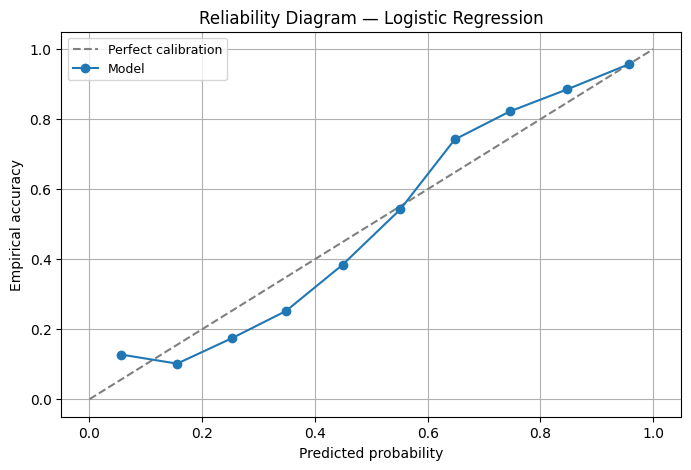

In [18]:
plot_reliability_diagram(
    y_true=y_test,
    y_prob=probs_lr,
    n_bins=10,
    title="Reliability Diagram — Logistic Regression"
)

### Observaciones — Reliability Diagram (Regresión Logística)

En la Regresión Logística, la curva del modelo sigue **razonablemente cerca**
de la diagonal de calibración perfecta.

Qué se observa:
- En probabilidades bajas y medias, el modelo **tiende a subestimar** ligeramente:
  cuando dice 30–40%, la frecuencia real es un poco mayor.
- En probabilidades medias–altas (≈0.6–0.8), el modelo se comporta de forma bastante coherente:
  lo que dice se acerca bien a lo que ocurre.
- En probabilidades muy altas (cerca de 1), la curva vuelve a alinearse con la diagonal.

Interpretación:
la Regresión Logística **no es perfectamente calibrada**, pero expresa la incertidumbre
de forma **suave y progresiva**.
Cuando se equivoca, suele hacerlo sin mostrarse extremadamente segura,
lo que reduce el riesgo operativo.

En resumen:
es un modelo que “habla con cautela”.

### 5.2) Árbol de Decisión — Reliability diagram

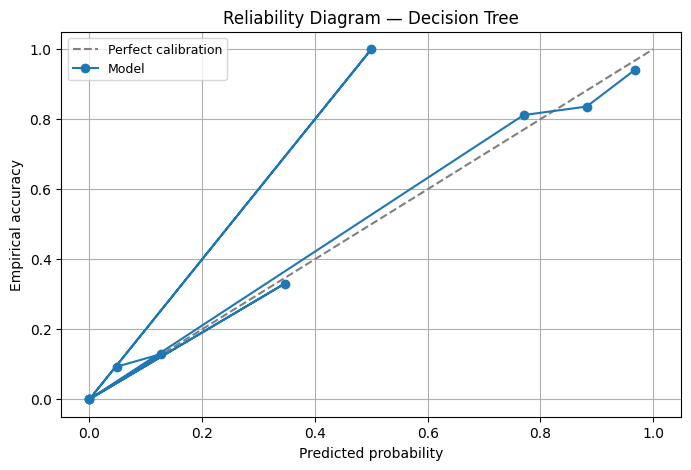

In [19]:
plot_reliability_diagram(
    y_true=y_test,
    y_prob=probs_tree,
    n_bins=10,
    title="Reliability Diagram — Decision Tree"
)

### Observaciones — Reliability Diagram (Árbol de Decisión)

En el Árbol de Decisión, la curva muestra un comportamiento **más irregular**
y con saltos bruscos.

Qué se observa:
- En probabilidades bajas, el modelo se comporta de forma razonable,
  aunque con pocos puntos intermedios.
- Aparecen **saltos grandes** entre bins, especialmente en probabilidades medias,
  lo que indica que muchos casos distintos reciben exactamente la misma probabilidad.
- En probabilidades altas (≈0.8–1.0), la curva cae **por debajo de la diagonal**,
  señal clara de **overconfidence**:
  el modelo dice “90%”, pero la frecuencia real es menor.

Interpretación:
el Árbol de Decisión tiende a **hablar en absolutos**.
Cuando asigna probabilidades altas, lo hace con mucha rigidez,
incluso en regiones donde los datos no justifican tanta seguridad.

Esto explica por qué:
- puede verse bien en métricas promedio,
- pero generar más errores con alta confianza.

En resumen:
es un modelo que “habla fuerte”, incluso cuando no debería.

---

### Conclusión y opinión — Reliability Diagrams

Las dos gráficas muestran de forma clara que **no todos los modelos expresan su confianza de la misma manera**, incluso cuando sus métricas numéricas parecen buenas.

La **Regresión Logística** presenta una curva relativamente cercana a la diagonal ideal.
Aunque no es perfecta, su comportamiento es **estable y progresivo**:
a medida que aumenta la probabilidad, también lo hace la frecuencia real.
Esto indica que el modelo tiende a **dosificar su seguridad** y a mostrar dudas cuando corresponde.

El **Árbol de Decisión**, en cambio, muestra una calibración **más irregular**.
Las probabilidades se concentran en pocos valores y aparecen saltos bruscos,
especialmente en rangos altos, donde el modelo se muestra **más seguro de lo que debería**.
La curva por debajo de la diagonal confirma un patrón de **overconfidence**.

La lectura conjunta es clara:
- el Árbol de Decisión “habla más fuerte”,
- la Regresión Logística “habla con más cautela”.

Aunque el Árbol puede parecer mejor en métricas promedio,
las gráficas muestran que su forma de expresar confianza es más riesgosa.
La Regresión Logística, aun siendo más simple,
comunica mejor su incertidumbre y resulta más predecible desde el punto de vista operativo.

Estas gráficas refuerzan una idea central del laboratorio:
**la confianza no solo se mide con números, también se entiende con forma**.

---
---

## Cierre del Día 2 — Auditoría de confianza

### Qué hicimos hoy
En este día realizamos una **auditoría completa de confianza** sobre dos modelos
(Regresión Logística y Árbol de Decisión), sin modificar ni calibrar nada.

El foco no estuvo en entrenar mejor,
sino en **medir cómo hablan los modelos cuando expresan confianza**.

---

### Qué aprendimos

1. **Las métricas dicen cosas distintas**
   - Accuracy y AUROC indican qué tan bien el modelo acierta u ordena.
   - Brier Score y ECE indican qué tan confiables son las probabilidades.

2. **Las métricas promedio no cuentan toda la historia**
   - El Árbol de Decisión obtiene mejores métricas promedio de confianza.
   - Sin embargo, comete más errores **cuando está muy seguro**.

3. **La forma importa**
   - La Regresión Logística muestra una calibración más suave y estable.
   - El Árbol de Decisión concentra su confianza y exagera seguridad en ciertos rangos.

4. **Confiabilidad ≠ rendimiento**
   - Un modelo puede verse “mejor” en números agregados
     y ser más riesgoso en los casos críticos.

---

### Decisión basada en confianza
Si la decisión se toma **solo por confianza** (ignorando accuracy):
- la **Regresión Logística** es más predecible y manejable,
- el **Árbol de Decisión** requiere corrección antes de usarse con confianza.

Esto no significa que uno sea “bueno” y el otro “malo”,
sino que **comunican la incertidumbre de forma muy distinta**.

---

### Conclusión clave del día
> Medir confianza no es un detalle técnico:  
> es una condición necesaria para tomar decisiones responsables.

Hoy aprendimos a **ver el problema con claridad**.

---

### Qué sigue
En el **Día 3** pasamos al siguiente paso natural:
- aplicar técnicas de **calibración post-hoc**,
- corregir probabilidades,
- y verificar si los modelos pueden aprender a decir
  números que realmente signifiquen lo que dicen.